# EEGNet — Motor Imagery Classification
**BCI Competition IV Dataset 2a** — 4 classes (left hand, right hand, feet, tongue)  
Pipeline: MNE loading → Preprocessing → EEGNet (TF/Keras) → Evaluation

Reference: Lawhern et al. (2018) *EEGNet: A compact convolutional neural network for EEG-based BCIs*

## 0. Environment & Imports

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import mne
from mne import Epochs, events_from_annotations
from mne.io import read_raw_gdf

import tensorflow as tf
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import (
    Conv2D, DepthwiseConv2D, SeparableConv2D,
    BatchNormalization, Activation, AveragePooling2D,
    Dropout, Flatten, Dense
)
from tensorflow.keras.constraints import max_norm
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report, cohen_kappa_score
from sklearn.model_selection import StratifiedKFold

mne.set_log_level('WARNING')
print(f'MNE {mne.__version__} | TF {tf.__version__}')

MNE 1.11.0 | TF 2.21.0


## 1. Dataset Setup

**Download:** BCI Competition IV Dataset 2a from https://www.bbci.de/competition/iv/  
Files needed per subject: `A0{1-9}T.gdf` (training) and `A0{1-9}E.gdf` (evaluation)  
Place them in `data/bcic_iv_2a/`

In [25]:
import os

# Working directory diagnosis
print(f'CWD: {os.getcwd()}')

# --- Paths ---
NOTEBOOK_DIR  = Path(r'C:\Users\pedro\Workspaces\EEG_learning')
DATA_DIR      = NOTEBOOK_DIR / 'data' / 'bcic_iv_2a'
LABELS_DIR    = NOTEBOOK_DIR / 'data' / 'true_labels'

# Dataset parameters
SFREQ        = 250
N_CHANNELS   = 22
N_CLASSES    = 4
CLASS_NAMES  = ['Left Hand', 'Right Hand', 'Feet', 'Tongue']

# Event codes in GDF annotations
EVENT_ID = {
    'left_hand':  769,
    'right_hand': 770,
    'feet':       771,
    'tongue':     772,
}
CODE_TO_IDX = {769: 0, 770: 1, 771: 2, 772: 3}

SUBJECTS = list(range(1, 10))
gdf_files = sorted(DATA_DIR.glob('*.gdf'))
print(f'DATA_DIR:   {DATA_DIR}')
print(f'LABELS_DIR: {LABELS_DIR}')
print(f'Found {len(gdf_files)} GDF files: {[f.name for f in gdf_files]}')

CWD: c:\Users\pedro\Workspaces\EEG_learning
DATA_DIR:   C:\Users\pedro\Workspaces\EEG_learning\data\bcic_iv_2a
LABELS_DIR: C:\Users\pedro\Workspaces\EEG_learning\data\true_labels
Found 18 GDF files: ['A01E.gdf', 'A01T.gdf', 'A02E.gdf', 'A02T.gdf', 'A03E.gdf', 'A03T.gdf', 'A04E.gdf', 'A04T.gdf', 'A05E.gdf', 'A05T.gdf', 'A06E.gdf', 'A06T.gdf', 'A07E.gdf', 'A07T.gdf', 'A08E.gdf', 'A08T.gdf', 'A09E.gdf', 'A09T.gdf']


## 2. Loading & Preprocessing

Pipeline per file:
1. Load GDF with MNE
2. Select EEG channels (drop EOG)
3. Bandpass filter 4–40 Hz
4. Epoch: cue onset → [0, 4] s (standard MI window)
5. Baseline correction

In [26]:
from scipy.io import loadmat

def load_subject(subject_id: int, split: str = 'T') -> tuple[np.ndarray, np.ndarray]:
    """
    Load, filter, and epoch one subject's data.
    Returns X: (n_epochs, n_channels, n_times), y: (n_epochs,) in {0,1,2,3}

    - split='T': labels come from GDF annotations (769–772)
    - split='E': trial onsets from GDF (code 783), labels from .mat file
    """
    fname = DATA_DIR / f'A0{subject_id}{split}.gdf'
    raw = read_raw_gdf(str(fname), preload=True, verbose=False)

    # Keep only EEG channels (drop EOG)
    raw.pick_types(eeg=True)
    raw.pick(raw.ch_names[:N_CHANNELS])

    # Bandpass filter
    raw.filter(l_freq=4.0, h_freq=40.0, method='iir', verbose=False)

    if split == 'T':
        # Training: class labels are embedded in annotations (769–772)
        ann_to_code = {str(k): k for k in CODE_TO_IDX}
        events, _ = mne.events_from_annotations(raw, event_id=ann_to_code, verbose=False)
        events = events[np.isin(events[:, 2], list(CODE_TO_IDX.keys()))]
        epoch_event_id = EVENT_ID

    else:
        # Evaluation: trials marked as 783 (unknown), labels from .mat
        events, _ = mne.events_from_annotations(raw, event_id={'783': 783}, verbose=False)
        mat = loadmat(str(LABELS_DIR / f'A0{subject_id}E.mat'))
        # classlabel: 1=left, 2=right, 3=feet, 4=tongue → shift to 0-indexed
        true_labels = mat['classlabel'].flatten() - 1   # shape (288,)
        # Map each trial to its synthetic event code so Epochs stays consistent
        # (we rebuild y from true_labels directly after epoching)
        epoch_event_id = {'cue': 783}

    epochs = mne.Epochs(
        raw, events,
        event_id=epoch_event_id,
        tmin=0.0, tmax=4.0,
        baseline=None,
        preload=True,
        verbose=False,
    )

    X = epochs.get_data().astype(np.float32)   # (n_epochs, 22, 1001)

    if split == 'T':
        y = np.array([CODE_TO_IDX[c] for c in epochs.events[:, 2]], dtype=np.int32)
    else:
        y = true_labels[:len(X)].astype(np.int32)  # match length in case of rejected trials

    return X, y


# Quick test
X1, y1 = load_subject(1, 'T')
print(f'Train — X: {X1.shape}, y: {y1.shape}')
X1e, y1e = load_subject(1, 'E')
print(f'Eval  — X: {X1e.shape}, y: {y1e.shape}')
print(f'Classes eval: {dict(zip(*np.unique(y1e, return_counts=True)))}')

C:\Users\pedro\scoop\apps\python\current\Lib\contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Train — X: (288, 22, 1001), y: (288,)


C:\Users\pedro\scoop\apps\python\current\Lib\contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Eval  — X: (288, 22, 1001), y: (288,)
Classes eval: {np.int32(0): np.int64(72), np.int32(1): np.int64(72), np.int32(2): np.int64(72), np.int32(3): np.int64(72)}


In [27]:
def load_all_subjects(split: str = 'T') -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Load all 9 subjects. Returns X, y, subject_ids."""
    Xs, ys, sids = [], [], []
    for sid in SUBJECTS:
        fpath = DATA_DIR / f'A0{sid}{split}.gdf'
        if not fpath.exists():
            print(f'  Skipping subject {sid} ({fpath.name} not found)')
            continue
        X, y = load_subject(sid, split)
        Xs.append(X)
        ys.append(y)
        sids.append(np.full(len(y), sid, dtype=np.int32))
        print(f'  Subject {sid}: {X.shape[0]} epochs')

    return np.concatenate(Xs), np.concatenate(ys), np.concatenate(sids)


# Load training splits
X_all, y_all, subject_ids = load_all_subjects('T')
print(f'\nTotal — X: {X_all.shape}, y: {y_all.shape}')

C:\Users\pedro\scoop\apps\python\current\Lib\contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


  Subject 1: 288 epochs


C:\Users\pedro\scoop\apps\python\current\Lib\contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


  Subject 2: 288 epochs


C:\Users\pedro\scoop\apps\python\current\Lib\contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


...

  Subject 7: 288 epochs


C:\Users\pedro\scoop\apps\python\current\Lib\contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


  Subject 8: 288 epochs


C:\Users\pedro\scoop\apps\python\current\Lib\contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


  Subject 9: 288 epochs

Total — X: (2592, 22, 1001), y: (2592,)


## 3. Normalization & Reshaping for EEGNet

EEGNet expects input `(batch, 1, n_channels, n_times)` — a single "image" with 1 "color" channel.

In [28]:
def normalize_per_epoch(X: np.ndarray) -> np.ndarray:
    """Z-score each epoch independently across channels × time."""
    mu  = X.mean(axis=(1, 2), keepdims=True)
    std = X.std(axis=(1, 2), keepdims=True) + 1e-8
    return (X - mu) / std


def reshape_for_eegnet(X: np.ndarray) -> np.ndarray:
    """(n, C, T) → (n, 1, C, T)  — channels-last not used; TF default is NHWC but
    EEGNet treats the signal as: H=channels, W=time, single input map."""
    return X[:, np.newaxis, :, :]    # (n, 1, C, T)


X_norm  = normalize_per_epoch(X_all)
X_ready = reshape_for_eegnet(X_norm)
print(f'Input tensor shape: {X_ready.shape}  →  (n_epochs, 1, {N_CHANNELS}, n_times)')

Input tensor shape: (2592, 1, 22, 1001)  →  (n_epochs, 1, 22, n_times)


## 4. EEGNet Architecture

From Lawhern et al. (2018), parameterized version:
- **Block 1:** Temporal Conv → DepthwiseConv (spatial) → BN → ELU → AvgPool → Dropout  
- **Block 2:** SeparableConv (temporal) → BN → ELU → AvgPool → Dropout  
- **Classifier:** Flatten → Dense(n_classes, softmax)

In [29]:
def build_eegnet(
    n_channels: int  = 22,
    n_times: int     = 1001,
    n_classes: int   = 4,
    sfreq: int       = 250,
    F1: int          = 8,      # number of temporal filters
    D: int           = 2,      # depth multiplier (spatial filters = F1*D)
    F2: int          = 16,     # pointwise filters in Block 2  (= F1*D)
    dropout_rate: float = 0.5,
) -> Model:
    """
    EEGNet as described in Lawhern et al. 2018.
    Input shape: (1, n_channels, n_times)  [channels_first]
    """
    kern_len = sfreq // 2   # temporal kernel = 0.5 s @ sfreq

    inputs = Input(shape=(1, n_channels, n_times), name='eeg_input')

    # --- Block 1 ---
    # Temporal convolution: learns frequency-specific filters
    x = Conv2D(
        filters=F1,
        kernel_size=(1, kern_len),
        padding='same',
        use_bias=False,
        data_format='channels_first',
        name='temporal_conv',
    )(inputs)
    x = BatchNormalization(axis=1)(x)

    # Depthwise spatial convolution: learns a spatial filter per temporal filter
    x = DepthwiseConv2D(
        kernel_size=(n_channels, 1),
        depth_multiplier=D,
        depthwise_constraint=max_norm(1.0),
        use_bias=False,
        data_format='channels_first',
        name='spatial_conv',
    )(x)
    x = BatchNormalization(axis=1)(x)
    x = Activation('elu')(x)
    x = AveragePooling2D(pool_size=(1, 4), data_format='channels_first')(x)
    x = Dropout(dropout_rate)(x)

    # --- Block 2 ---
    # Separable conv: depthwise + pointwise, learns temporal relationships
    x = SeparableConv2D(
        filters=F2,
        kernel_size=(1, 16),
        padding='same',
        use_bias=False,
        data_format='channels_first',
        name='separable_conv',
    )(x)
    x = BatchNormalization(axis=1)(x)
    x = Activation('elu')(x)
    x = AveragePooling2D(pool_size=(1, 8), data_format='channels_first')(x)
    x = Dropout(dropout_rate)(x)

    # --- Classifier ---
    x = Flatten()(x)
    outputs = Dense(
        n_classes,
        activation='softmax',
        kernel_constraint=max_norm(0.25),
        name='classifier',
    )(x)

    model = Model(inputs, outputs, name='EEGNet')
    return model


# Infer n_times from loaded data
n_times = X_ready.shape[-1]
model   = build_eegnet(N_CHANNELS, n_times, N_CLASSES, SFREQ)
model.summary()

Model: "EEGNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ eeg_input (InputLayer)          │ (None, 1, 22, 1001)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ temporal_conv (Conv2D)          │ (None, 8, 22, 1001)    │         1,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 8, 22, 1001)    │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_conv (DepthwiseConv2D)  │ (None, 16, 1, 1001)    │           352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 16, 1, 1001)    │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 16, 1, 1001)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_6             │ (None, 16, 1, 250)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 16, 1, 250)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv                  │ (None, 16, 1, 250)     │           512 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 16, 1, 250)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 16, 1, 250)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_7             │ (None, 16, 1, 31)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 16, 1, 31)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 496)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier (Dense)              │ (None, 4)              │         1,988 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,012 (15.67 KB)

 Trainable params: 3,932 (15.36 KB)

 Non-trainable params: 80 (320.00 B)

## 5. Training — Within-Subject (Subject 1)

Using the standard train/test split: `A0xT.gdf` for training, `A0xE.gdf` for testing.

In [30]:
SUBJECT_ID = 1   # change to run any subject

# Load train (T) and evaluation (E) splits
X_train, y_train = load_subject(SUBJECT_ID, 'T')
X_test,  y_test  = load_subject(SUBJECT_ID, 'E')

X_train = reshape_for_eegnet(normalize_per_epoch(X_train))
X_test  = reshape_for_eegnet(normalize_per_epoch(X_test))

print(f'Train: {X_train.shape} | Test: {X_test.shape}')
print(f'Class dist train: {dict(zip(*np.unique(y_train, return_counts=True)))}')
print(f'Class dist test:  {dict(zip(*np.unique(y_test,  return_counts=True)))}')

C:\Users\pedro\scoop\apps\python\current\Lib\contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)
C:\Users\pedro\scoop\apps\python\current\Lib\contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Train: (288, 1, 22, 1001) | Test: (288, 1, 22, 1001)
Class dist train: {np.int32(0): np.int64(72), np.int32(1): np.int64(72), np.int32(2): np.int64(72), np.int32(3): np.int64(72)}
Class dist test:  {np.int32(0): np.int64(72), np.int32(1): np.int64(72), np.int32(2): np.int64(72), np.int32(3): np.int64(72)}


In [31]:
# Build & compile
model = build_eegnet(N_CHANNELS, n_times, N_CLASSES, SFREQ)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-5),
]

history = model.fit(
    X_train, y_train,
    epochs=300,
    batch_size=32,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/300
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 198ms/step - accuracy: 0.2435 - loss: 1.4086 - val_accuracy: 0.2069 - val_loss: 1.3863 - learning_rate: 0.0010
Epoch 2/300
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 175ms/step - accuracy: 0.3478 - loss: 1.3556 - val_accuracy: 0.2414 - val_loss: 1.3861 - learning_rate: 0.0010
Epoch 3/300
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 180ms/step - accuracy: 0.3348 - loss: 1.3639 - val_accuracy: 0.2069 - val_loss: 1.3860 - learning_rate: 0.0010
Epoch 4/300
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 203ms/step - accuracy: 0.4174 - loss: 1.3339 - val_accuracy: 0.1897 - val_loss: 1.3856 - learning_rate: 0.0010
Epoch 5/300
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 172ms/step - accuracy: 0.4304 - loss: 1.3095 - val_accuracy: 0.2069 - val_loss: 1.3846 - learning_rate: 0.0010
Epoch 6/300
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 169ms/step - accuracy: 0.4913 - loss: 1.2762 - val_accuracy: 0.2069 - val_loss: 1.3828 - learning_rate: 0.0010
Epoch 7/300
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 157ms/step - accuracy: 0.5435 - loss: 1.2348 - val_acc

## 6. Evaluation

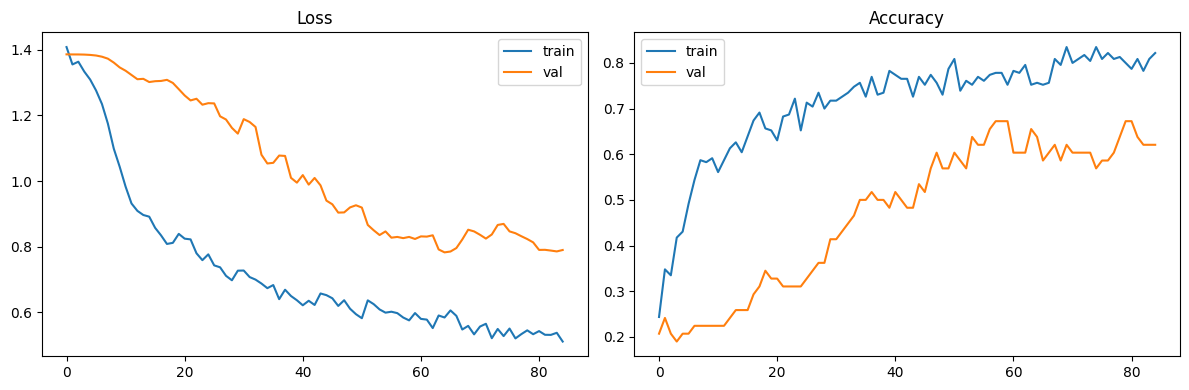

In [32]:
# Training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['loss'], label='train')
axes[0].plot(history.history['val_loss'], label='val')
axes[0].set_title('Loss'); axes[0].legend()
axes[1].plot(history.history['accuracy'], label='train')
axes[1].plot(history.history['val_accuracy'], label='val')
axes[1].set_title('Accuracy'); axes[1].legend()
plt.tight_layout()
plt.show()

In [33]:
# Test-set evaluation
y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)

acc   = (y_pred == y_test).mean()
kappa = cohen_kappa_score(y_test, y_pred)

print(f'Subject {SUBJECT_ID} — Accuracy: {acc:.4f} | Cohen\'s κ: {kappa:.4f}')
print()
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Subject 1 — Accuracy: 0.6667 | Cohen's κ: 0.5556

              precision    recall  f1-score   support

   Left Hand       0.79      0.67      0.72        72
  Right Hand       0.79      0.94      0.86        72
        Feet       0.50      0.53      0.51        72
      Tongue       0.58      0.53      0.55        72

    accuracy                           0.67       288
   macro avg       0.67      0.67      0.66       288
weighted avg       0.67      0.67      0.66       288



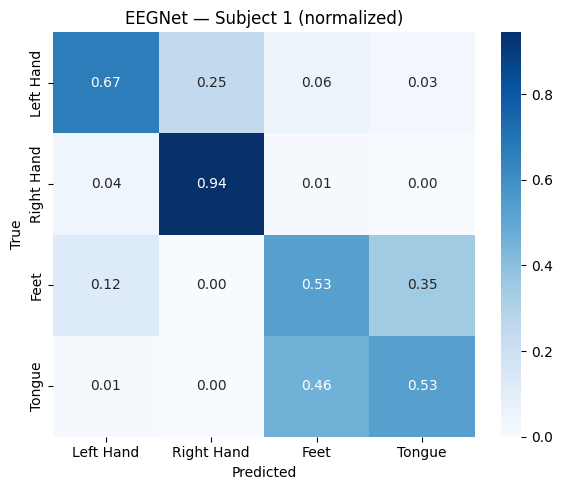

In [34]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred, normalize='true')
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='.2f', cmap='Blues',
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES
)
plt.ylabel('True'); plt.xlabel('Predicted')
plt.title(f'EEGNet — Subject {SUBJECT_ID} (normalized)')
plt.tight_layout()
plt.show()

## 7. Cross-Subject Evaluation (Leave-One-Subject-Out)

Train on 8 subjects, test on the held-out subject — gives a more generalisable performance estimate.

In [35]:
def run_loso(subjects=SUBJECTS, epochs_fit=300, batch_size=32):
    results = []

    for test_sub in subjects:
        train_subs = [s for s in subjects if s != test_sub]

        # Collect training data from all other subjects
        Xtr, ytr = [], []
        for s in train_subs:
            if not (DATA_DIR / f'A0{s}T.gdf').exists():
                continue
            X_, y_ = load_subject(s, 'T')
            Xtr.append(X_); ytr.append(y_)
        Xtr = np.concatenate(Xtr)
        ytr = np.concatenate(ytr)

        # Test subject
        X_te, y_te = load_subject(test_sub, 'E')

        # Normalize & reshape
        Xtr = reshape_for_eegnet(normalize_per_epoch(Xtr))
        X_te = reshape_for_eegnet(normalize_per_epoch(X_te))

        nt = Xtr.shape[-1]
        m  = build_eegnet(N_CHANNELS, nt, N_CLASSES, SFREQ)
        m.compile(
            optimizer=tf.keras.optimizers.Adam(1e-3),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'],
        )
        m.fit(
            Xtr, ytr,
            epochs=epochs_fit, batch_size=batch_size,
            validation_split=0.1,
            callbacks=[EarlyStopping(patience=15, restore_best_weights=True)],
            verbose=0,
        )

        y_pred = np.argmax(m.predict(X_te), axis=1)
        acc    = (y_pred == y_te).mean()
        kappa  = cohen_kappa_score(y_te, y_pred)
        results.append({'subject': test_sub, 'accuracy': acc, 'kappa': kappa})
        print(f'  LOSO — test_sub={test_sub}: acc={acc:.4f}, κ={kappa:.4f}')

    return results


# Uncomment to run (takes several minutes)
# loso_results = run_loso()
print('run_loso() defined — uncomment last line to execute.')

run_loso() defined — uncomment last line to execute.


In [36]:
# Plot LOSO summary (run after run_loso)
# import pandas as pd
# df = pd.DataFrame(loso_results)
# print(df.describe())
# df.plot(x='subject', y=['accuracy', 'kappa'], kind='bar', figsize=(10,4))
# plt.title('LOSO — EEGNet per subject'); plt.tight_layout(); plt.show()

## 8. Save & Load Model

In [37]:
MODELS_DIR = Path('models')
MODELS_DIR.mkdir(exist_ok=True)

model_path = MODELS_DIR / f'eegnet_subject{SUBJECT_ID}.keras'
model.save(model_path)
print(f'Saved: {model_path}')

# Reload:
# model_loaded = tf.keras.models.load_model(model_path)

Saved: models\eegnet_subject1.keras


In [38]:
import mne
from mne.io import read_raw_gdf
from pathlib import Path
import numpy as np

DATA_DIR = Path(r'C:\Users\pedro\Workspaces\EEG_learning\data\bcic_iv_2a')
raw_e = read_raw_gdf(str(DATA_DIR / 'A01E.gdf'), preload=False, verbose=False)

print("Descriptions únicas nas annotations:")
print(np.unique(raw_e.annotations.description))


Descriptions únicas nas annotations:
['1023' '1072' '276' '277' '32766' '768' '783']


C:\Users\pedro\scoop\apps\python\current\Lib\contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


In [39]:
import mne
from mne.io import read_raw_gdf
from pathlib import Path
import numpy as np

DATA_DIR = Path(r'C:\Users\pedro\Workspaces\EEG_learning\data\bcic_iv_2a')
raw_e = read_raw_gdf(str(DATA_DIR / 'A01E.gdf'), preload=False, verbose=False)

print("Descriptions únicas nas annotations:")
print(np.unique(raw_e.annotations.description))


Descriptions únicas nas annotations:
['1023' '1072' '276' '277' '32766' '768' '783']


C:\Users\pedro\scoop\apps\python\current\Lib\contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


In [42]:
from pathlib import Path
DATA_DIR = Path(r'C:\Users\pedro\Workspaces\EEG_learning\data\true_labels')
mat_files = sorted(DATA_DIR.glob('*.mat'))
print(f'Arquivos .mat encontrados: {[f.name for f in mat_files]}')


Arquivos .mat encontrados: ['A01E.mat', 'A01T.mat', 'A02E.mat', 'A02T.mat', 'A03E.mat', 'A03T.mat', 'A04E.mat', 'A04T.mat', 'A05E.mat', 'A05T.mat', 'A06E.mat', 'A06T.mat', 'A07E.mat', 'A07T.mat', 'A08E.mat', 'A08T.mat', 'A09E.mat', 'A09T.mat']
